In [1]:
import tensorflow as tf

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt


In [4]:
import os

In [5]:
import random 

In [6]:
import shutil

In [7]:
from PIL import Image

In [8]:
def split_dataset(source_dir, output_dir,train_percentage=80):
    classes = ["Cat", "Dog"]
    for class_name in classes:
        source_class = os.path.join(source_dir,class_name)
        images = []
        for file in os.listdir(source_class):
            if file.lower().endswith((".jpg", "jpeg",".png",".bmp",".webp") ):
                images.append(file)
                random.shuffle(images)
        split_index = int(len(images) * train_percentage / 100) 
        train_images = images[:split_index]
        test_images= images[split_index:]
        train_folder = os.path.join(output_dir, "train", class_name)
        test_folder = os.path.join(output_dir, "test", class_name)
        os.makedirs(train_folder, exist_ok=True )
        os.makedirs(test_folder,  exist_ok=True )
        for image in train_images:
            shutil.copy2(
                os.path.join(source_class, image) , 
                os.path.join(train_folder, image))
        for image in test_images:
            shutil.copy2(os.path.join(source_class, image) , 
            os.path.join(test_folder, image))
    print("Dataset split complete ")

In [9]:
#split_dataset(source_dir="dataset", output_dir="cats_dogs_split", train_percentage=80)

In [12]:
for root, dirs , files in os.walk("cats_dogs_split"):
    for file in files:
        path = os.path.join(root, file)
        try:
            img = Image.open(path)
            img = img.convert("RGB")
            img = img.resize((128,128))
            img.save(path)
        except :
            os.remove(path)
            print("deleted ", path)
print("Cleaning DOne ")

D:\Anaconda-summer2026\Lib\site-packages\PIL\TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Cleaning DOne 


In [13]:
train_datset = tf.keras.utils.image_dataset_from_directory(
    "cats_dogs_split/train",
    image_size=(128,128),
    batch_size=32

)

Found 19967 files belonging to 2 classes.


In [14]:
test_datset = tf.keras.utils.image_dataset_from_directory(
    "cats_dogs_split/test",
    image_size=(128,128),
    batch_size=32

)

Found 4992 files belonging to 2 classes.


In [15]:
train_datset.class_names

['Cat', 'Dog']

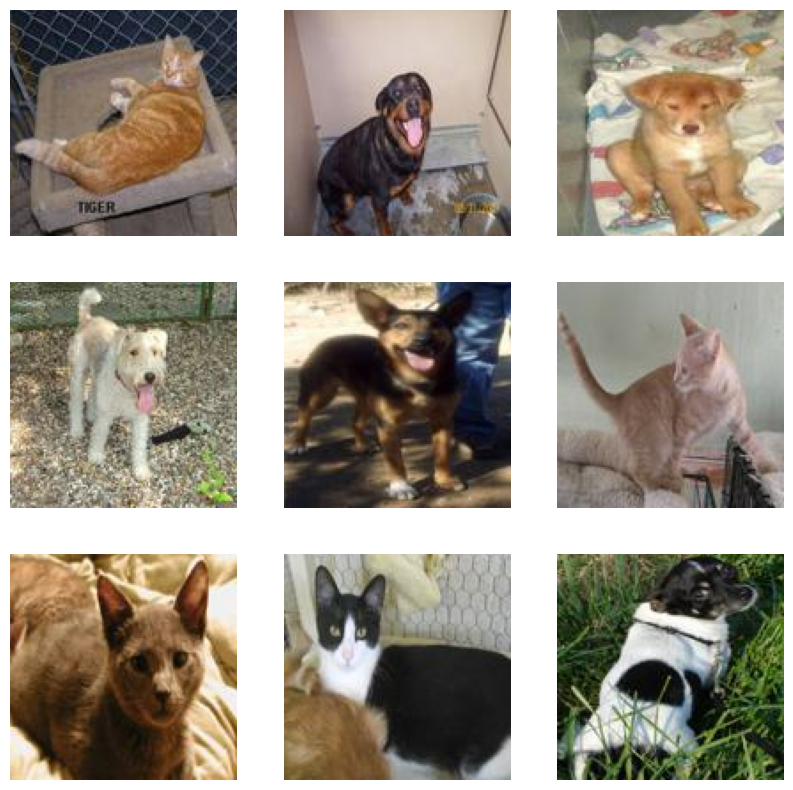

In [17]:
plt.figure(figsize=(10,10))

for images , labels in train_datset.take(1):
    for i in range(9):
        plt.subplot(3 , 3 , i + 1)
        plt.imshow(images[i].numpy().astype("uint8") )
        plt.axis("off")

plt.show()

In [18]:
model = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255),
    tf.keras.layers.Conv2D(
    32,
    (3,3),
    activation="relu"
    
    
    ),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(
        64,
        (3,3),
        activation="relu"
    ),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(
        128,
        (3,3),
        activation="relu"
    ),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(
        128,
        activation="relu"
    ),
    tf.keras.layers.Dense(
        1,
        activation="sigmoid"
    )
    
]

    
)

In [19]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [20]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [21]:
history = model.fit (
    train_datset,
    validation_data=test_datset,
    epochs=10
)

Epoch 1/10
624/624 ━━━━━━━━━━━━━━━━━━━━ 60s 93ms/step - accuracy: 0.6633 - loss: 0.6015 - val_accuracy: 0.7035 - val_loss: 0.5613
Epoch 2/10
624/624 ━━━━━━━━━━━━━━━━━━━━ 52s 83ms/step - accuracy: 0.7688 - loss: 0.4832 - val_accuracy: 0.7354 - val_loss: 0.5163
Epoch 3/10
624/624 ━━━━━━━━━━━━━━━━━━━━ 54s 87ms/step - accuracy: 0.8160 - loss: 0.4064 - val_accuracy: 0.8181 - val_loss: 0.4003
Epoch 4/10
624/624 ━━━━━━━━━━━━━━━━━━━━ 55s 88ms/step - accuracy: 0.8512 - loss: 0.3359 - val_accuracy: 0.8047 - val_loss: 0.4611
Epoch 5/10
624/624 ━━━━━━━━━━━━━━━━━━━━ 55s 88ms/step - accuracy: 0.8922 - loss: 0.2546 - val_accuracy: 0.8107 - val_loss: 0.4803
Epoch 6/10
624/624 ━━━━━━━━━━━━━━━━━━━━ 56s 90ms/step - accuracy: 0.9332 - loss: 0.1674 - val_accuracy: 0.8155 - val_loss: 0.5625
Epoch 7/10
624/624 ━━━━━━━━━━━━━━━━━━━━ 56s 90ms/step - accuracy: 0.9638 - loss: 0.0969 - val_accuracy: 0.8009 - val_loss: 0.6982
Epoch 8/10
624/624 ━━━━━━━━━━━━━━━━━━━━ 54s 86ms/step - accuracy: 0.9761 - loss: 0.0685 - 

In [22]:
loss , accuracy = model.evaluate(test_datset)

156/156 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.8047 - loss: 0.9904


In [23]:
print(loss)

0.9903948903083801


In [24]:
print(accuracy)

0.8046875


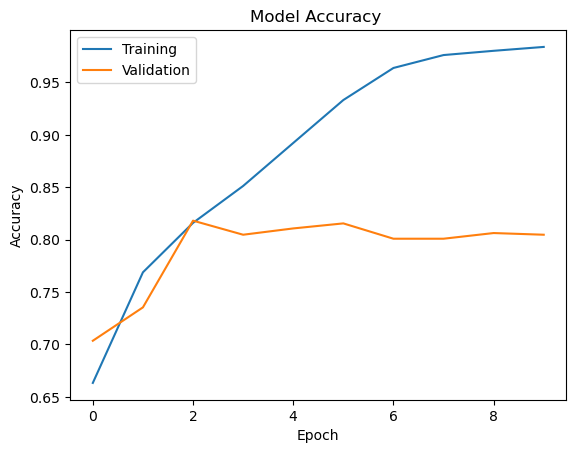

In [28]:
plt.plot(history.history["accuracy"])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy ")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Training", "Validation"])
plt.show()

In [29]:
img = tf.keras.preprocessing.image.load_img(

    "2355.jpg",
    target_size=(128,128)
)

In [30]:
img_array = tf.keras.preprocessing.image.img_to_array(img)

In [31]:
img_array = np.expand_dims(img_array, axis=0)

In [32]:
predtion = model.predict(img_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step


In [33]:
if predtion[0][0] > 0.5 :
    print("DOG")
else:
    print("Cat")

DOG
